## Importing Required Libraries

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Metrics and Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Ensure Reproducibility
torch.manual_seed(42)



## Loading and Exploring the Iris Dataset

In [ ]:
# Load the Iris dataset
iris_data = pd.read_csv('iris.csv')

# Splitting Features and Target Variable

In [ ]:
# Separate Features (X) and Target (y)
features = iris_data.drop('species', axis=1)
labels = iris_data['species']

# Display the feature matrix and target vector
print(features.head())
print(labels.head())



   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object


## Normalizing Feature Values Using Min-Max Scaling

In [ ]:
# One-Hot Encode the target labels for multi-class classification
encoded_labels = pd.get_dummies(labels)

# Display the encoded labels
encoded_labels.head()


,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


## Splitting Data

In [ ]:
# Split  training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(features, encoded_labels, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Prepare DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


## Converting Data to Tensors

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid.values, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)


## Creating Data Loaders

In [ ]:
batch_size = 32

train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_valid, y_valid)
test_data = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)


## Defining the Neural Network Architecture

In [ ]:
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.softmax(self.fc3(x), dim=1)
        return x

# Instantiate the model
model = IrisNet()


## Setting Loss Function, Optimizer, and Training Parameters

In [ ]:

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


## Training the Model

In [ ]:
# Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        # Forward pass
        predictions = model(X_batch)
        loss = loss_fn(predictions, torch.argmax(y_batch, dim=1))

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Print loss for every 10th epoch
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}, Loss: {epoch_loss / len(train_loader):.4f}')



Epoch 10, Loss: 0.6070
Epoch 20, Loss: 0.5776
Epoch 30, Loss: 0.5737
Epoch 40, Loss: 0.5769
Epoch 50, Loss: 0.5791


## Evaluating the Model on Test Data

In [ ]:
# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            preds = model(X_batch)
            all_preds.append(preds)
            all_labels.append(y_batch)

    # Concatenate all predictions and labels
    predictions = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    predicted_classes = torch.argmax(predictions, dim=1)
    true_classes = torch.argmax(labels, dim=1)

    # Calculate Accuracy
    accuracy = accuracy_score(true_classes, predicted_classes)
    print(f'Accuracy: {accuracy:.4f}')

    # Confusion Matrix and Classification Report
    print('Confusion Matrix:\n', confusion_matrix(true_classes, predicted_classes))
    print('Classification Report:\n', classification_report(true_classes, predicted_classes))

evaluate(model, test_loader)



Accuracy: 1.0000
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Generating and Plotting Confusion Matrix

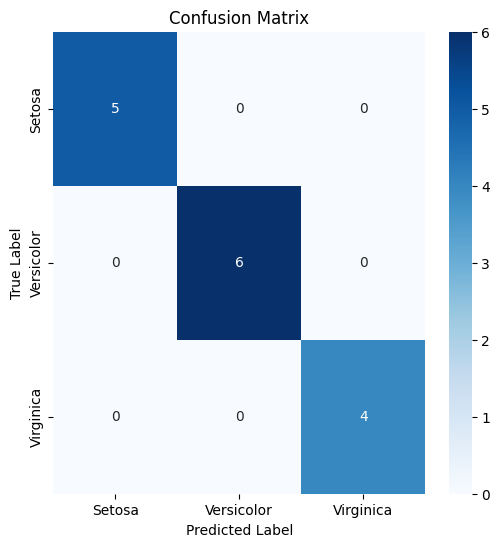

In [ ]:
conf_matrix = confusion_matrix(actual_labels, test_predictions)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Plotting ROC Curves for Each Class

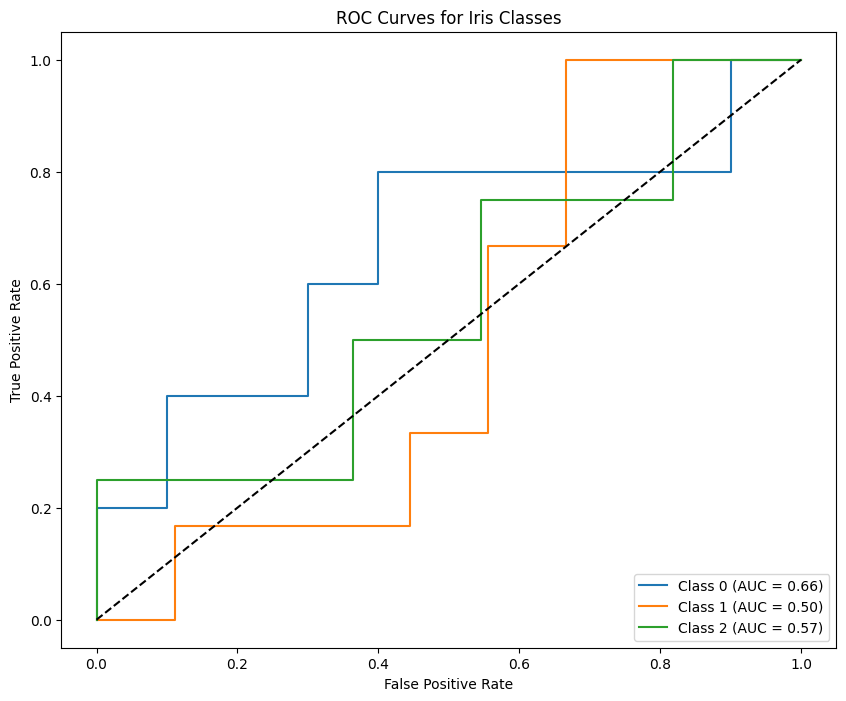

In [ ]:
actual_binarized = label_binarize(actual_labels, classes=[0, 1, 2])
test_scores = model(X_valid).detach().numpy()

plt.figure(figsize=(10, 8))
for i in range(3):
    fpr, tpr, _ = roc_curve(actual_binarized[:, i], test_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Iris Classes')
plt.legend(loc='lower right')
plt.show()
